# Modules

In [ ]:
%pip install --upgrade datasets
%pip install --upgrade huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 19.4 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.3/553.3 kB 13.0 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.4.0
    Uninstalling huggingface_hub-1.4.0:
      Successfully uninstalled huggingface_hub-1.4.0


In [ ]:
# Base --------------------------------------------------
import os
import sys
import numpy as np
import pandas as pd
import json
import logging
from subprocess import Popen, PIPE, STDOUT
from textwrap import TextWrapper

# PyTorch -----------------------------------------------
import torch

# Transformers ------------------------------------------
from transformers import AutoModelForQuestionAnswering, pipeline
from transformers import AutoTokenizer

# Hugging Face -----------------------------------------
from huggingface_hub import login, list_datasets, notebook_login
from datasets import load_dataset, get_dataset_config_names

# Viz --------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
from IPython.display import set_matplotlib_formats

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

Let's now log into HuggingFace

In [ ]:
login()

# Data set

In [ ]:
# just clearing the cache
!rm -rf ~/.cache/huggingface

The data set we are going to use is found [here](https://huggingface.co/datasets/megagonlabs/subjqa). We paste the summary here:

"SubjQA is a question answering dataset that focuses on subjective (as opposed to factual) questions and answers. The dataset consists of roughly 10,000 questions over reviews from 6 different domains: books, movies, grocery, electronics, TripAdvisor (i.e. hotels), and restaurants. Each question is paired with a review and a span is highlighted as the answer to the question (with some questions having no answer). Moreover, both questions and answer spans are assigned a subjectivity label by annotators. Questions such as "How much does this product weigh?" is a factual question (i.e., low subjectivity), while "Is this easy to use?" is a subjective question (i.e., high subjectivity).

In short, SubjQA provides a setting to study how well extractive QA systems perform on finding answer that are less factual and to what extent modeling subjectivity can improve the performance of QA systems."

This data contains different domains that we can use: books, electronics, grocery, movies, restaurants, and tripadvisor. Note, however, that the way to load the dataset and the domains is not anymore as what the page says: that is the old way which has been updated.

Now Hugging Face removed support for loading datasets via Python builder scripts (like subjqa.py). To load it without forcing a downgrade is to load SubjQA from its Parquet conversion branch (refs/convert/parquet) instead of the script-based main. SubjQA does have that branch, with per-domain folders.

Let's load three different domains: books, electronics, and movies (here we will only analyse electronics)

In [ ]:
def load_subjqa_domain(domain):
    base = "hf://datasets/megagonlabs/subjqa@refs/convert/parquet"
    data_files = {
        "train":      f"{base}/{domain}/train/*.parquet",
        "validation": f"{base}/{domain}/validation/*.parquet",
        "test":       f"{base}/{domain}/test/*.parquet",
    }
    return load_dataset("parquet", data_files=data_files)

subjqa_electronics = load_subjqa_domain("electronics")
subjqa_books       = load_subjqa_domain("books")
subjqa_movies      = load_subjqa_domain("movies")

books/train/0000.parquet:   0%|          | 0.00/1.49M [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/297k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/404k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

...

0000.parquet:   0%|          | 0.00/379k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/396k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Let's see how it looks like

In [ ]:
subjqa_electronics['train'].features

{'domain': Value('string'),
 'nn_mod': Value('string'),
 'nn_asp': Value('string'),
 'query_mod': Value('string'),
 'query_asp': Value('string'),
 'q_reviews_id': Value('string'),
 'question_subj_level': Value('int64'),
 'ques_subj_score': Value('float32'),
 'is_ques_subjective': Value('bool'),
 'review_id': Value('string'),
 'id': Value('string'),
 'title': Value('string'),
 'context': Value('string'),
 'question': Value('string'),
 'answers': {'text': List(Value('string')),
  'answer_start': List(Value('int32')),
  'answer_subj_level': List(Value('int64')),
  'ans_subj_score': List(Value('float32')),
  'is_ans_subjective': List(Value('bool'))}}

out of all the data, what matters mostly for us are: title, question, context, and answers, where this last one has subparts. For example

In [ ]:
print(subjqa_electronics["train"]["answers"][1])

{'text': ['Bass is weak as expected', 'Bass is weak as expected, even with EQ adjusted up'], 'answer_start': [1302, 1302], 'answer_subj_level': [1, 1], 'ans_subj_score': [0.5083333253860474, 0.5083333253860474], 'is_ans_subjective': [True, True]}


Let's see now what is our data made of!

In [ ]:
dfs = {split: dset.to_pandas() for split, dset in subjqa_electronics.flatten().items()}

for split, df in dfs.items():
    print(f"Number of questions in {split}: {df['id'].nunique()}")

Number of questions in train: 1295
Number of questions in validation: 255
Number of questions in test: 358


then we only have 1908 examples in total (and it makes sense as a real life scenario, since getting domain experts to label extractive QA datasets is an intensive labor... and very expensive!).



# Question/Answering

When we look for information about anything we may be in a situation were the question is clear and objective and receives an objective answer, for example: "When did Marie Curie win her two Nobel Prizes?" In this case the answer is clear: 1903 (Physics) and 1911 (Chemistry). What you may get from Google is this

<br>

![Marie Curie](https://drive.google.com/uc?export&id=12sg8kk-OpT3mGHNlzABbsUMkh6pdnii4)

However, when we make a subjective question like "Which guitar is better a Gibson Xplorer Custom or a Dean Z Select Fluence Black Satin?" you do not receive an answer, but the links to many web pages tht you can use to get the answer by yourself.

This process is what we know as Question Answering and is trickier than it may seem at the beginning. There are different approaches:

 * Extractive QA, which involves questions whose answer can be identified as a span of text in a document. The idea is to first retrieve the relevant documents and then extract the answer from them.
 * Community QA, which involves gathering paris of question-answer that are generated by users in forums, then use semantic similarity to find the closest answer to a new question
 * Long-term QA, which aims to generate complex paragraph-length answers to open-ended questions like "How do you see your future?"

The dataset with consumer reviews can be used as a rich source of information, and along the way we will learn how transformers act as powerful reading comprehension models that can extract meaning from the text.

Let's take a closer look to a few of the examples (randomly select 2 of them) of the data

In [ ]:
qa_cols = ["title", "question", "answers.text",
           "answers.answer_start", "context"]
sample_df = dfs["train"][qa_cols].sample(2, random_state=7)
sample_df

,title,question,answers.text,answers.answer_start,context
791,B005DKZTMG,Does the keyboard lightweight?,[this keyboard is compact],[215],I really like this keyboard. I give it 4 star...
1159,B00AAIPT76,How is the battery?,[],[],I bought this after the first spare gopro batt...


We see some important features of the data:

 * Some questions (most?) are not grammatically correct
 * An empty `answer.text` denotes unaswerable questions whose answer cannot be found in the review
 * We can use the start index and the length of the answer span slice out the span of text in the review that corresponds to the answer

In [ ]:
start_idx = sample_df["answers.answer_start"].iloc[0][0]
end_idx = start_idx + len(sample_df["answers.text"].iloc[0][0])
sample_df["context"].iloc[0][start_idx:end_idx]

'this keyboard is compact'

Understanding that this is a very language dependent analysis, let's see which type of question is more common

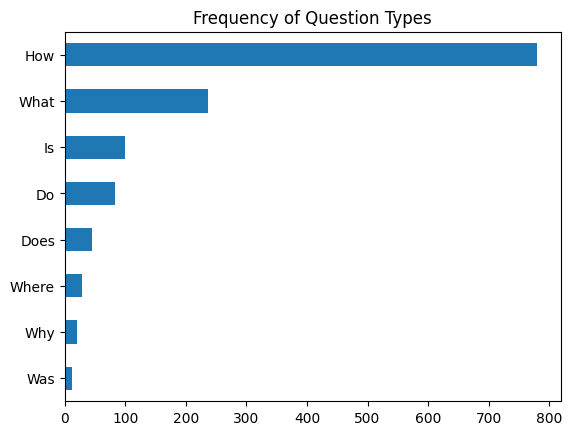

In [ ]:
counts = {}
question_types = ["What", "How", "Is", "Does", "Do", "Was", "Where", "Why"]

for q in question_types:
    counts[q] = dfs["train"]["question"].str.startswith(q).value_counts()[True]

pd.Series(counts).sort_values().plot.barh()
plt.title("Frequency of Question Types")
plt.show()

then clearly "How" questions, then "What" questions are the most common. Let's see some examples

In [ ]:
for question_type in ["How", "What"]:
    for question in (
        dfs["train"][dfs["train"].question.str.startswith(question_type)]
        .sample(n=3, random_state=42)['question']):
        print(question)

How is the camera?
How do you like the control?
How fast is the charger?
What is direction?
What is the quality of the construction of the bag?
What is your impression of the product?


## Extracting Answers from Text

The first thing that our model needs to do is recognize the potential answer as a span of text in the customer review, then we need to understand how to:

 * Frame the supervised learning problem
 * Tokenize and encode text for QA tasks
 * Deal with long passages that exceed the model's maximum context size

### Span Classification

The most common way to extract answers from text is by framing the problem as a spam classification task, where the start and end tokens of an answer span act as the labels that a model needs to predict. The process is illustrate below (image taken from "Natural Language Processing with Transformers")

<br>

![Marie Curie](https://drive.google.com/uc?export&id=12N98C_zfSFAsu_iYHc1VO7Lv2tuaPOcT)


A good strategy is to start with a language model that has already been fine-tuned on a large-scale QA dataset (we can do so since the structure of labels remains the same across datasets).

### Tokenizing text for QA

We will select MiniLM, a distilled version of BERT-base pretrained with the dataset SQuAD (the Standford QA dataset) which has 66M parameters and an F-score of 79.5 with the SQuAD 2.0 dataset. There are many different alternatives: RoBERTa-base, ALBERT-XXL, XML-RoBERTa-large,...

In [ ]:
model_ckpt = "deepset/minilm-uncased-squad2"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

config.json:   0%|          | 0.00/477 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/107 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Let's try to extract an answer from a short passage of text. In extractive QA, the inputs are supplied: question and context:

In [ ]:
question = "How much music can this hold?"
context = """An MP3 is about 1 MB/minute, so about 6000 hours depending on file size."""
inputs = tokenizer(question, context, return_tensors="pt")

The return is a PyTorch tensor since we need it for the forward pass

In [ ]:
input_df = pd.DataFrame.from_dict(tokenizer(question, context), orient="index")
input_df

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
input_ids,101,2129,2172,2189,2064,2023,2907,1029,102,2019,...,2061,2055,25961,2847,5834,2006,5371,2946,1012,102
token_type_ids,0,0,0,0,0,0,0,0,0,1,...,1,1,1,1,1,1,1,1,1,1
attention_mask,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


Remember this structure with the input_ids and the attention_mask? We have another piece of information: token_type_ids now indicates which part of the input correspond to the question (0) and which to the context (1).

This is what we have in our inputs

In [ ]:
print(tokenizer.decode(inputs["input_ids"][0]))

[CLS] how much music can this hold? [SEP] an mp3 is about 1 mb / minute, so about 6000 hours depending on file size. [SEP]


and so we have the structure [CLS] question tokens [SEP] context tokens [SEP], that we could see in the previous image.

Now we can instantiate our model with QA head and run the inputs through the forward pass

In [ ]:
model = AutoModelForQuestionAnswering.from_pretrained(model_ckpt)

with torch.no_grad():
    outputs = model(**inputs)
print(outputs)

model.safetensors:   0%|          | 0.00/133M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForQuestionAnswering LOAD REPORT from: deepset/minilm-uncased-squad2
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


QuestionAnsweringModelOutput(loss=None, start_logits=tensor([[-0.9862, -4.7750, -5.4025, -5.2378, -5.2863, -5.5117, -4.9819, -6.1880,
         -0.9862,  0.2596, -0.2144, -1.7136,  3.7806,  4.8561, -1.0546, -3.9097,
         -1.7374, -4.5944, -1.4278,  3.9949,  5.0391, -0.2018, -3.0193, -4.8549,
         -2.3107, -3.5110, -3.5713, -0.9862]]), end_logits=tensor([[-0.9623, -5.4733, -5.0326, -5.1639, -5.4278, -5.5151, -5.1749, -4.6233,
         -0.9623, -3.7855, -0.8715, -3.7745, -3.0161, -1.1780,  0.1758, -2.7365,
          4.8934,  0.3046, -3.1761, -3.2762,  0.8937,  5.6606, -0.3623, -4.9554,
         -3.2531, -0.0914,  1.6211, -0.9623]]), hidden_states=None, attentions=None)


we get a QuestionAnsweringModelOutput object as the output of a QA head. This corresponds to a linear layer that takes the hidden states from the encoder and computes the logits for the start and end spans.

To convert this into an answering span we need start and end tokens

In [ ]:
start_logits = outputs.start_logits
end_logits = outputs.end_logits

Let's see the shapes of these logits and the one of the input tensors

In [ ]:
print(f"Input IDs shape: {inputs.input_ids.size()}")
print(f"Start logits shape: {start_logits.size()}")
print(f"End logits shape: {end_logits.size()}")

Input IDs shape: torch.Size([1, 28])
Start logits shape: torch.Size([1, 28])
End logits shape: torch.Size([1, 28])


In these tensors, the larger positive logits correspond to more likely candidates for the start and end tokens

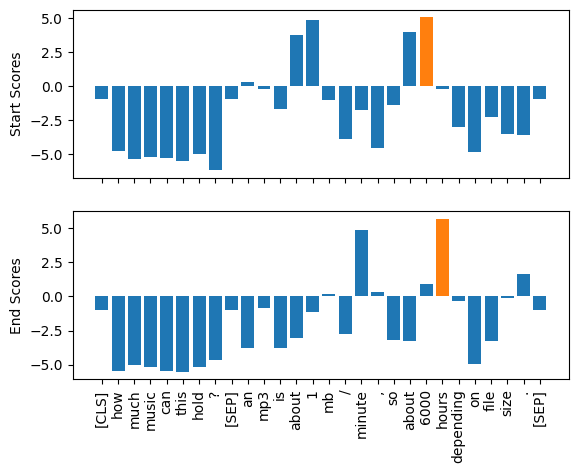

In [ ]:
s_scores = start_logits.detach().numpy().flatten()
e_scores = end_logits.detach().numpy().flatten()
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
token_ids = range(len(tokens))

fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True)
colors = ["C0" if s != np.max(s_scores) else "C1" for s in s_scores]
ax1.bar(x=token_ids, height=s_scores, color=colors)
ax1.set_ylabel("Start Scores")
colors = ["C0" if s != np.max(e_scores) else "C1" for s in e_scores]
ax2.bar(x=token_ids, height=e_scores, color=colors)
ax2.set_ylabel("End Scores")
plt.xticks(token_ids, tokens, rotation="vertical")
plt.show()

In the start we have the numbers "1" and "6000", while in the end we have "minute" and "hours", with the largest in both being "6000" and "hours".

To get the final answer we can compute the argmax over the start and en token logits and then slice the span from the inputs

In [ ]:
start_idx = torch.argmax(start_logits)
end_idx = torch.argmax(end_logits) + 1
answer_span = inputs["input_ids"][0][start_idx:end_idx]
answer = tokenizer.decode(answer_span)
print(f"Question: {question}")
print(f"Answer: {answer}")

Question: How much music can this hold?
Answer: 6000 hours


So... it worked!

### What about a pipeline?

Yes, it worked but took us some time... In transformers we may use a dedicated pipeline instantiated by passing or tokenizer and the fine-tuned model

In [ ]:
pipe = pipeline("question-answering", model=model, tokenizer=tokenizer)
pipe(question=question, context=context, top_k=3)

[{'score': 0.265162855386734, 'start': 38, 'end': 48, 'answer': '6000 hours'},
 {'score': 0.22082918882369995,
  'start': 16,
  'end': 48,
  'answer': '1 MB/minute, so about 6000 hours'},
 {'score': 0.10253456234931946,
  'start': 16,
  'end': 27,
  'answer': '1 MB/minute'}]

then again... do you remember the top_k argument? With the pipeline we obtained the three most probable answers, which as you see are giving us the same information.

## Dealing with long passages

Fine, we have a working environment but it happens that in many cases, the input is longer than the maximum available size for the model's context: in the case of MiniLM it is of 512 tokens. Let's see how many cases we have in our data set  

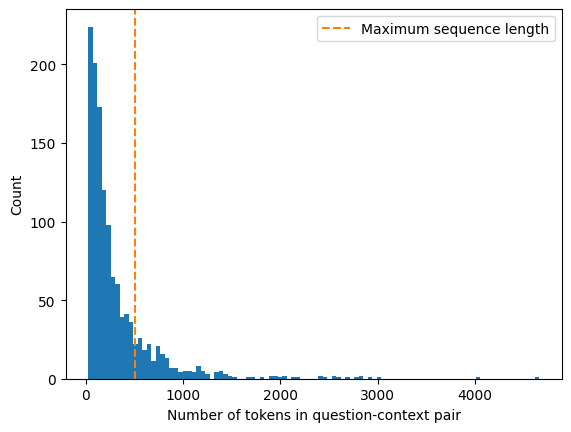

In [ ]:
def compute_input_length(row):
    inputs = tokenizer(row["question"], row["context"])
    return len(inputs["input_ids"])

dfs["train"]["n_tokens"] = dfs["train"].apply(compute_input_length, axis=1)

fig, ax = plt.subplots()
dfs["train"]["n_tokens"].hist(bins=100, grid=False, ec="C0", ax=ax)
plt.xlabel("Number of tokens in question-context pair")
ax.axvline(x=512, ymin=0, ymax=1, linestyle="--", color="C1",
           label="Maximum sequence length")
plt.legend()
plt.ylabel("Count")
plt.show()

For question answering the strategy of truncating the input is not a valid one because the answer may well lie at the end of the context and we would loose it. The technique that is used is that of sliding window across the inputs, where each window contains a passage of tokens that fit in the model's context. For this:

  * the `return_overflowing_tokens=True` option enables the sliding window
  * the `max_length=100`is the length of the window


In [ ]:
example = dfs["train"].iloc[0][["question", "context"]]
tokenized_example = tokenizer(example["question"], example["context"],
                              return_overflowing_tokens=True, max_length=100,
                              stride=25)

In this case, the example is

In [ ]:
example.loc['question', ]

'How is the bass?'

In [ ]:
example.loc['context', ]

'I have had Koss headphones in the past, Pro 4AA and QZ-99.  The Koss Portapro is portable AND has great bass response.  The work great with my Android phone and can be "rolled up" to be carried in my motorcycle jacket or computer bag without getting crunched.  They are very light and do not feel heavy or bear down on your ears even after listening to music with them on all day.  The sound is night and day better than any ear-bud could be and are almost as good as the Pro 4AA.  They are "open air" headphones so you cannot match the bass to the sealed types, but it comes close. For $32, you cannot go wrong.'

and we get a list of input_ids, one for each window

In [ ]:
for idx, window in enumerate(tokenized_example['input_ids']):
  print(f'Window #{idx} has {len(window)} tokens')

Window #0 has 100 tokens
Window #1 has 88 tokens


In [ ]:
for window in tokenized_example["input_ids"]:
    print(f"{tokenizer.decode(window)} \n")

[CLS] how is the bass? [SEP] i have had koss headphones in the past, pro 4aa and qz - 99. the koss portapro is portable and has great bass response. the work great with my android phone and can be " rolled up " to be carried in my motorcycle jacket or computer bag without getting crunched. they are very light and do not feel heavy or bear down on your ears even after listening to music with them on all day. the sound is [SEP] 

[CLS] how is the bass? [SEP] and do not feel heavy or bear down on your ears even after listening to music with them on all day. the sound is night and day better than any ear - bud could be and are almost as good as the pro 4aa. they are " open air " headphones so you cannot match the bass to the sealed types, but it comes close. for $ 32, you cannot go wrong. [SEP] 

